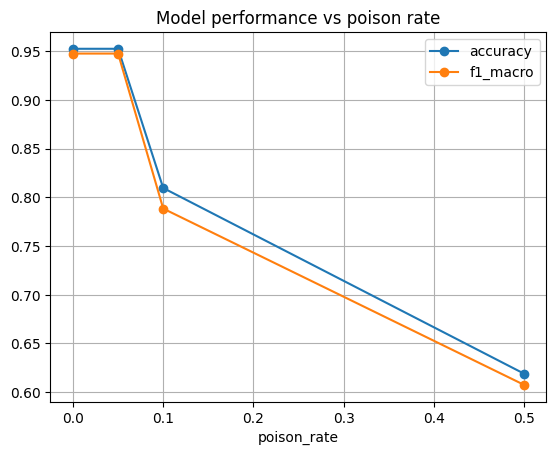

In [3]:
import mlflow
from mlflow import MlflowClient
import pandas as pd
import matplotlib.pyplot as plt

mlflow.set_tracking_uri("http://127.0.0.1:8100")
client = MlflowClient(mlflow.get_tracking_uri())
exp = client.get_experiment_by_name("iris-poisoning-experiments")
runs = client.search_runs(exp.experiment_id, order_by=["metrics.accuracy DESC"])

# Build table of poison_rate -> metrics
rows = []
for r in runs:
    p = float(r.data.params.get("poison_rate", 0))
    rows.append({
        "run_id": r.info.run_id,
        "poison_rate": p,
        "accuracy": float(r.data.metrics.get("accuracy", 0)),
        "f1_macro": float(r.data.metrics.get("f1_macro", 0))
    })
df = pd.DataFrame(rows)
df = df.sort_values("poison_rate")
df.plot(x="poison_rate", y=["accuracy", "f1_macro"], marker='o', grid=True)
plt.title("Model performance vs poison rate")
plt.show()